### Here we go over some of the examples of the general capabilities related to the usage of Sandy and FRENDY with WINDIGO ###

Let's first go over functionality related to Sandy.

In [14]:
#We first import the WINDIGO module with our Jupyter notebook
#We will also import other useful modules
import WINDIGO
import os
import numpy as np

Depending on how your virtual environment is set up, you may get issues with Sandy not being able to access your NJOY installation when using Jupyter notebooks. This can be fixed using the following lines:

In [15]:
os.environ["NJOY"] = "/home/jacob/miniconda3/envs/openmc-env/bin/njoy"

Let's retrieve some covariance matrices using Sandy. For this case, we will assume that we are investigating Be9's elastic scattering cross section data. We will use the CASMO12 energy grid given here: https://serpent.vtt.fi/mediawiki/index.php/CASMO_12-group_structure


 njoy 2016.78  03Feb25                                       04/05/26 17:47:24
 *****************************************************************************

 moder...                                                                 0.0s

 reconr...                                                                0.0s

 broadr...                                                                0.0s

 thermr...                                                                0.0s

 wrote thermal data for temp = 5.0000E+02                                 0.1s

 heatr...                                                                 0.1s

 heatr...                                                                 0.1s

 gaspr...                                                                 0.1s

 purr...                                                                  0.1s

 mat =  425                                                               0.1s

 ---message from purr---mat  425 has no 

('covarianceMatrix_13Groups_Be9_MT_2_Absolute.csv',
 'covariancePlot_13Groups_Be9MT2_Absolute.png')

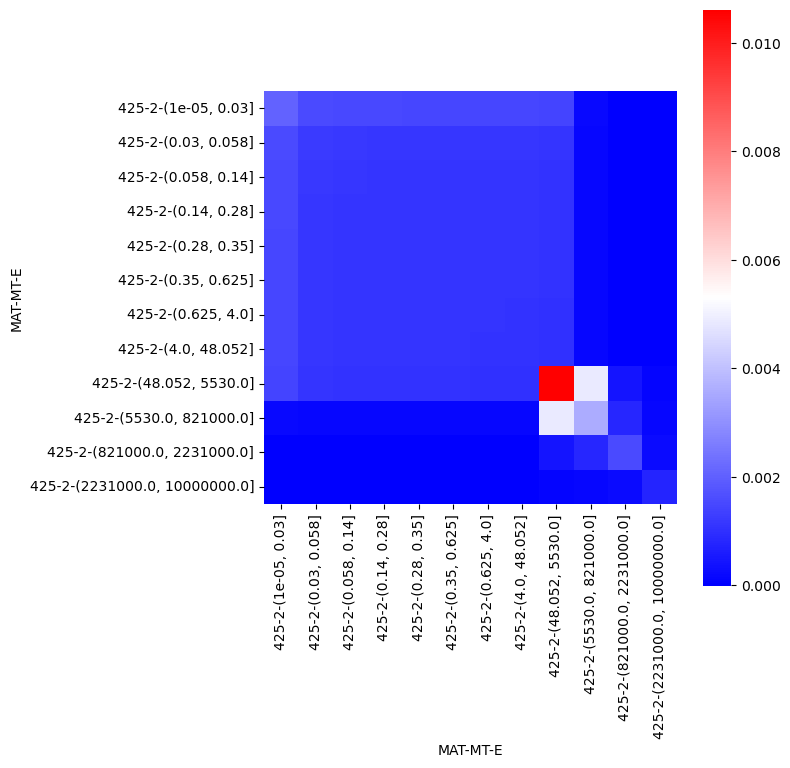

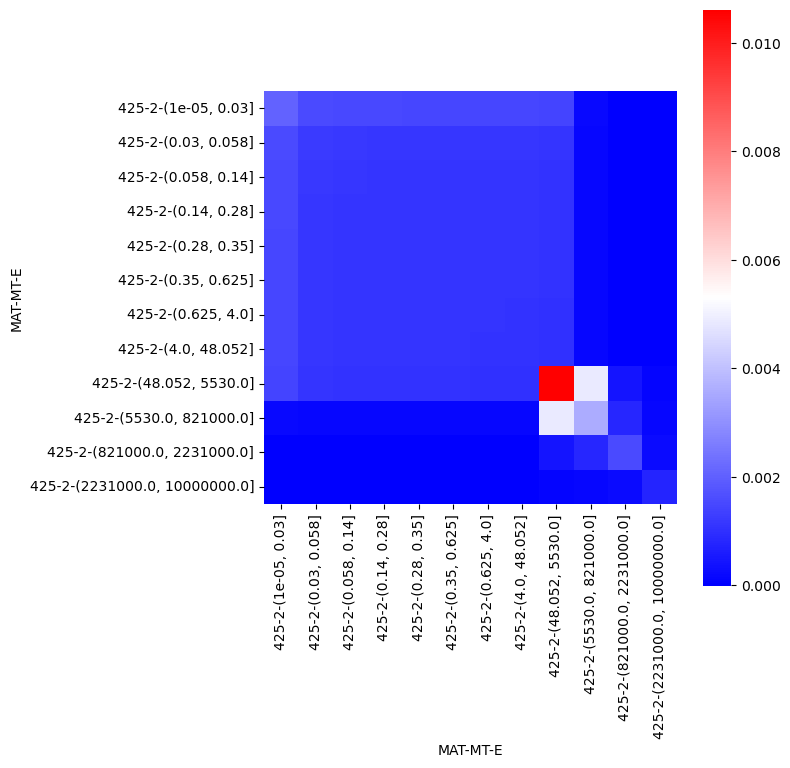

In [ ]:
#Specify the energy grid of choice to retrieve the covariance data for

energy_grid_CASMO = np.array([1.0E-11, 3.0E-8, 5.8E-8, 1.4E-7, 2.8E-7, 3.5E-7,
                              6.25E-7, 4.0E-6, 4.8052E-5, 5.530E-3, 8.21E-1,
                              2.231E0, 1.0E1])

#Convert the energy grid from MeV to eV

energy_grid_CASMO = energy_grid_CASMO * 10**6

#Let's first retrieve the absolute covariance matrix using Sandy
#While not needed for generating or manipulating cross sections, the absolute
#covariance matrix is needed to perform uncertainty quantification through the 
#direct perturbation methodology.

WINDIGO.sandy_covariance_retrieval(energy_grid = energy_grid_CASMO,
                                   nuclide = 'Be9',
                                   mt_Number = 2,
                                   data_library = 'endfb_80',
                                   temperature = 500,
                                   relative_Flag = False,
                                   plotting_Flag = True)

#We'll then retrieve the relative covariance matrix using Sandy
#We will use it to assist with generating cross section data with randomly
#sampled perturbation coefficients.

WINDIGO.sandy_covariance_retrieval(energy_grid = energy_grid_CASMO,
                                   nuclide = 'Be9',
                                   mt_Number = 2,
                                   data_library = 'endfb_80',
                                   temperature = 500,
                                   relative_Flag = True,
                                   plotting_Flag = True)